First cluster


In [1]:
%load_ext autoreload
%matplotlib inline

In [12]:
%autoreload 2
import sys
import os

current_dir = os.getcwd()

if current_dir not in sys.path:
    sys.path.insert(0, current_dir)
from model import *
from load_data import *
from utils import *

In [6]:
EPOCH=150

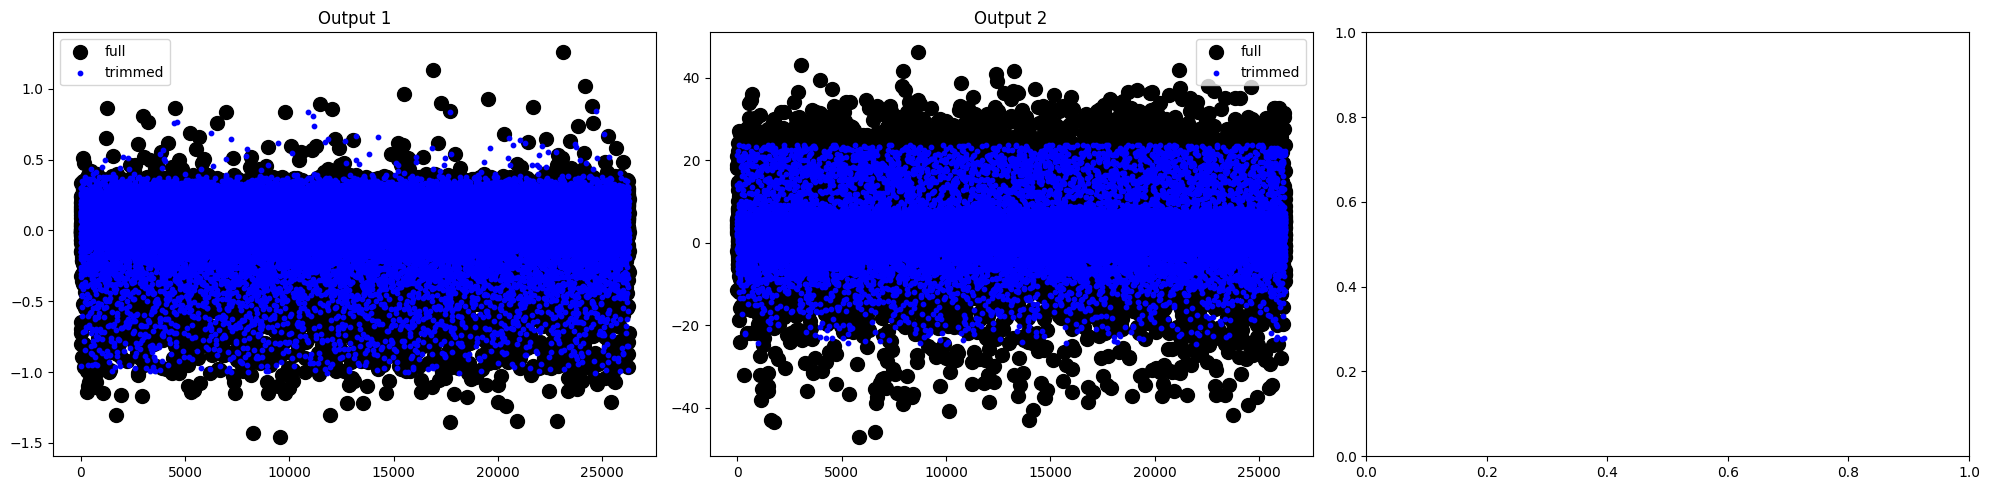

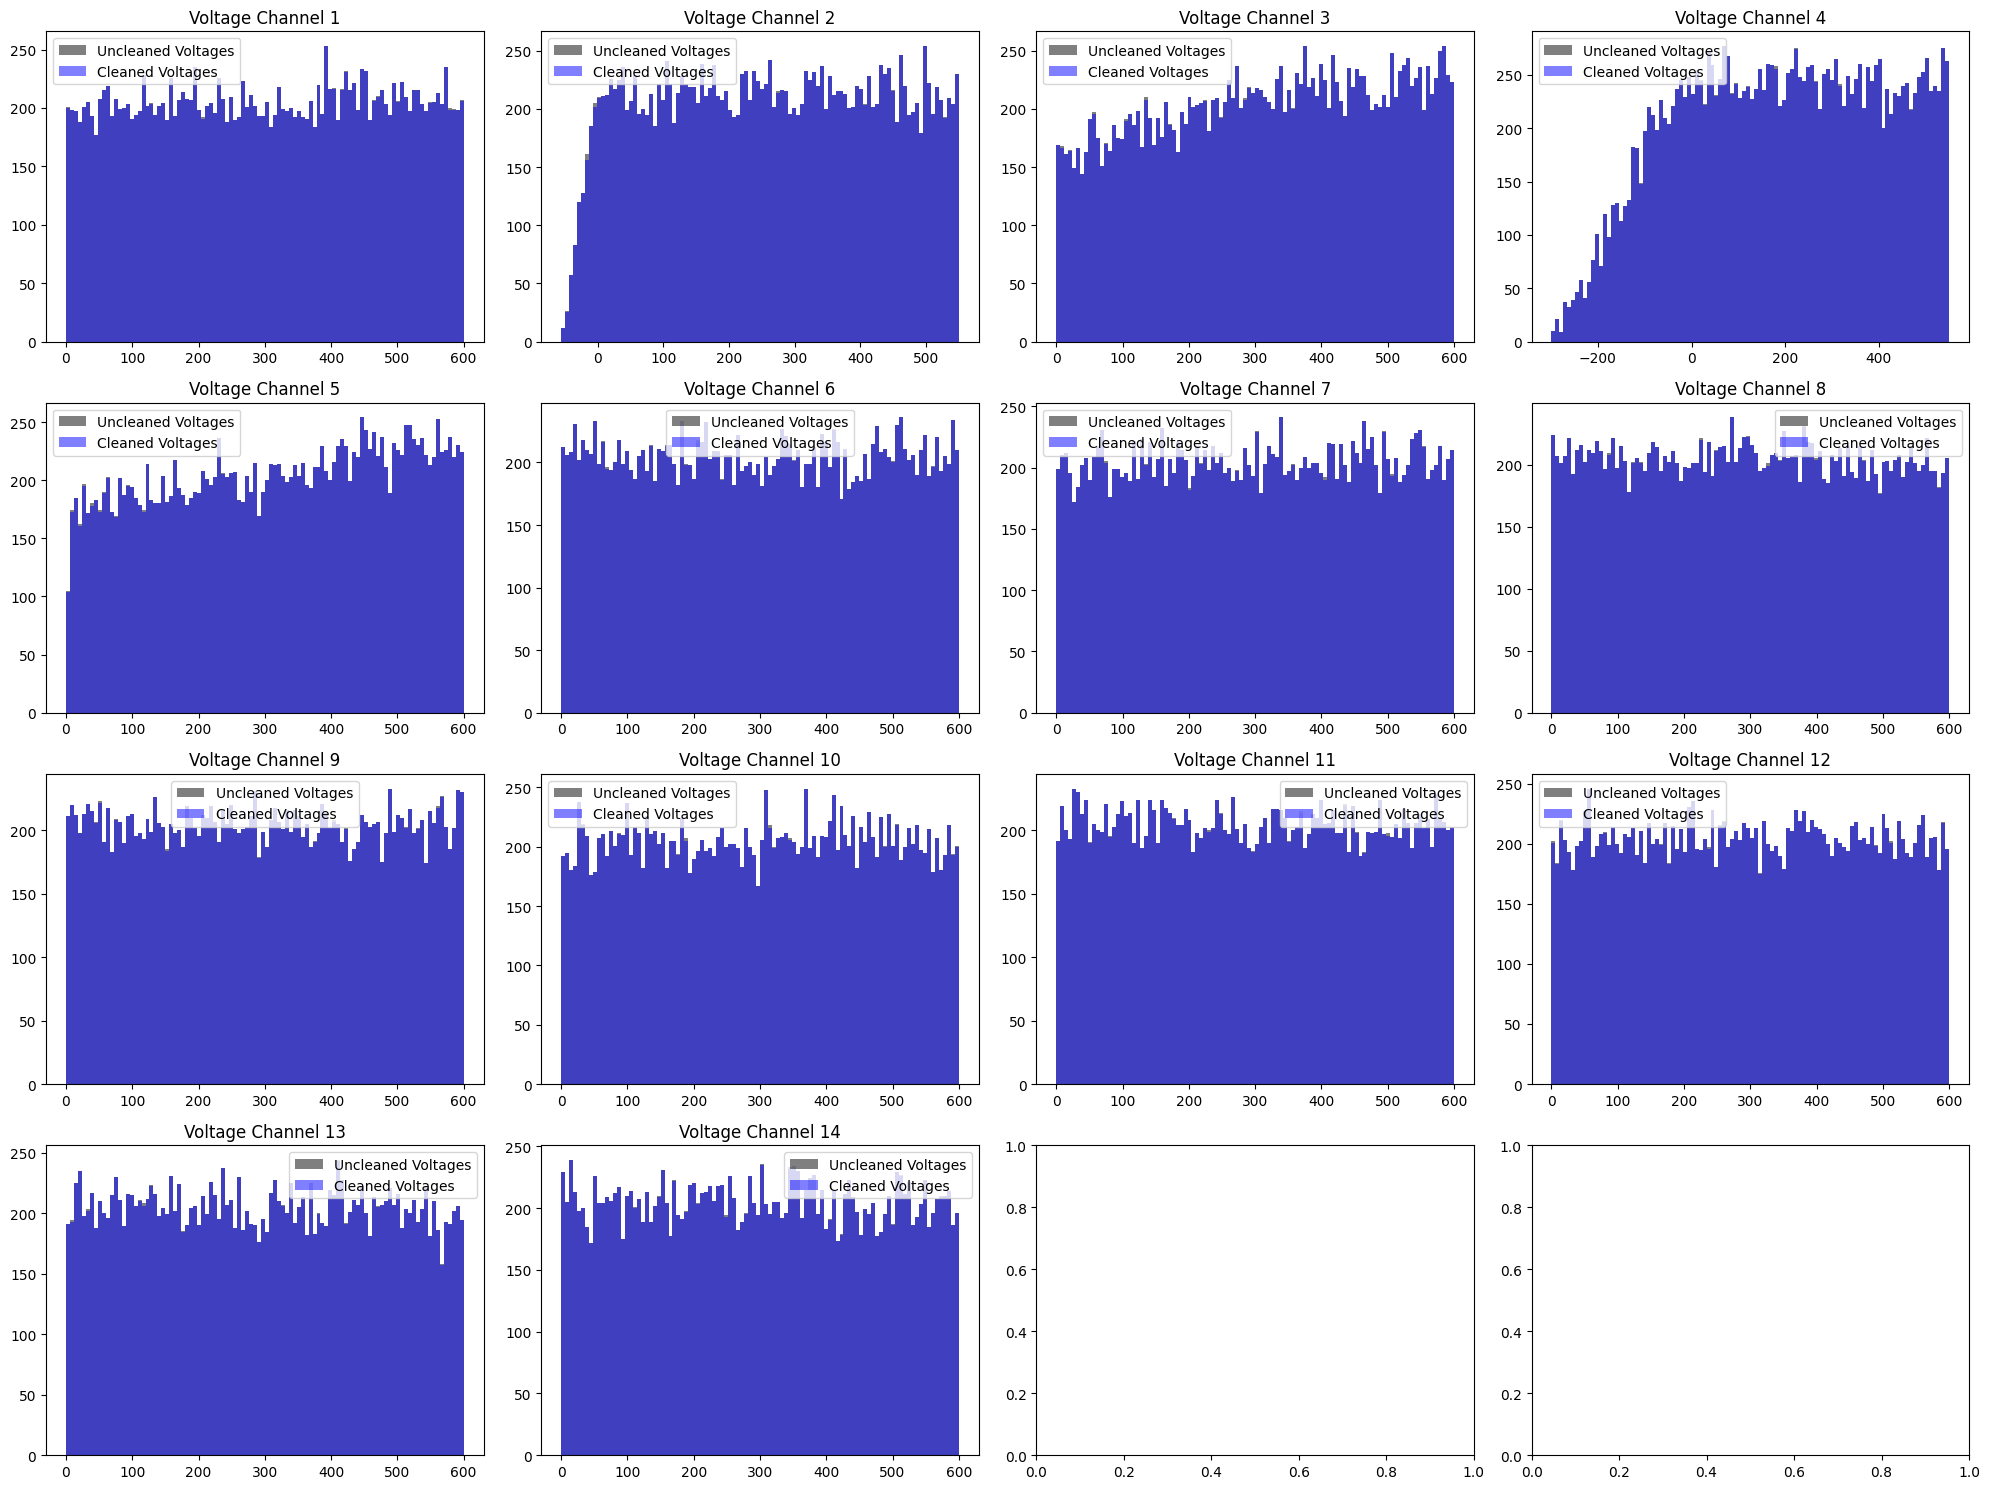

99.9% of data retained after cleaning


In [7]:
threshold = 4
trim_mode = "iqr"
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
    trim_mode=trim_mode,
    trim_threshold=threshold,
    subplot_shape=(1, 3),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)
# ax[0].set_ylim(-5, 5)
_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        # "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
    trim_mode=trim_mode,
    trim_threshold=threshold,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 0.772989, Val Loss = 0.527502
Training completed. Best validation loss: 0.527502


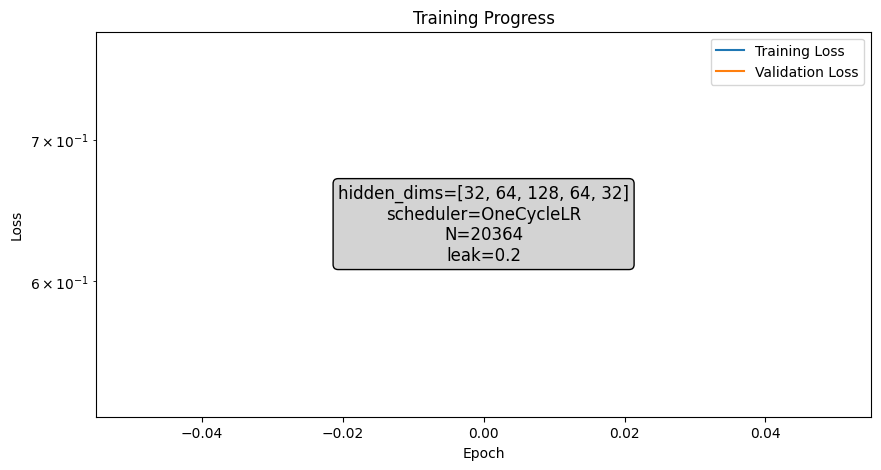

In [9]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 2  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_outputs = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_outputs,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor1 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, leak=0.2
)
print("Training model...")
predictor1.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model1.pt",
)


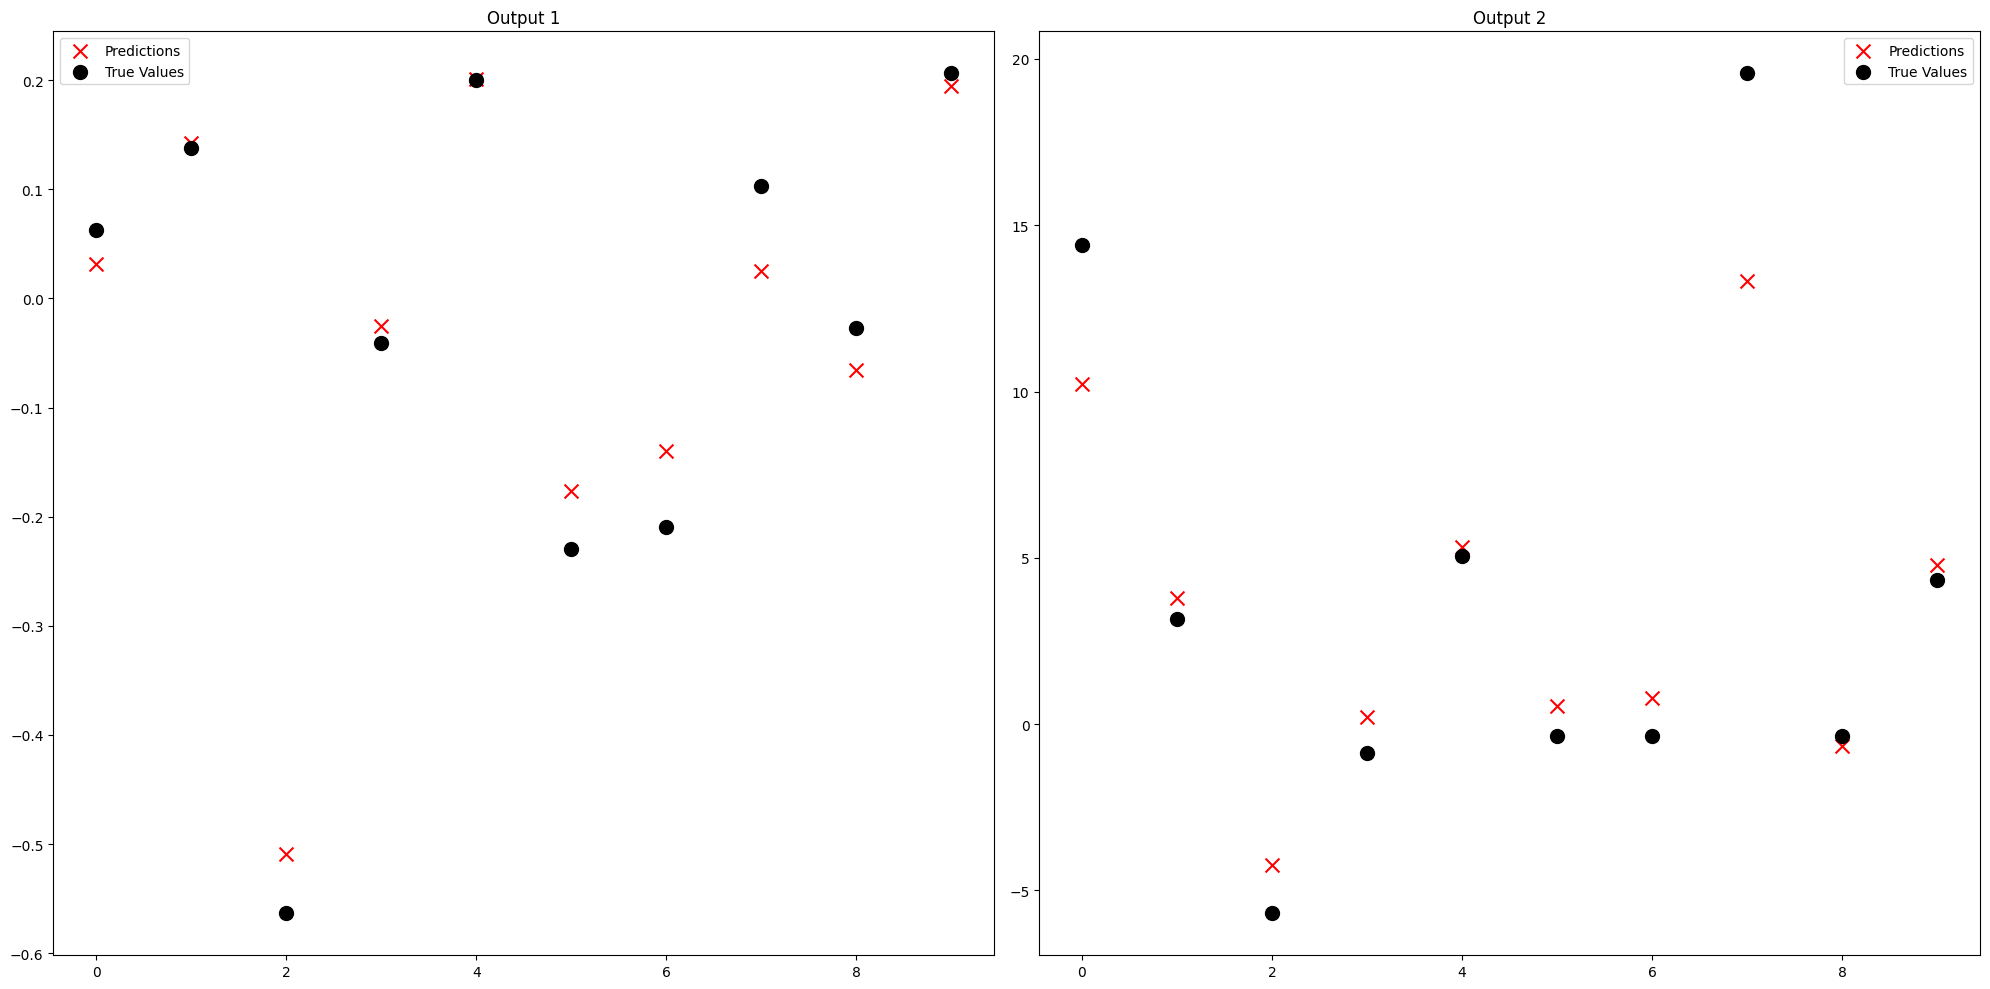

In [ ]:
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor1, n_samples=10, subplot_shape=(1, 2)
)

cluster 2

79.3% of data retained after cleaning


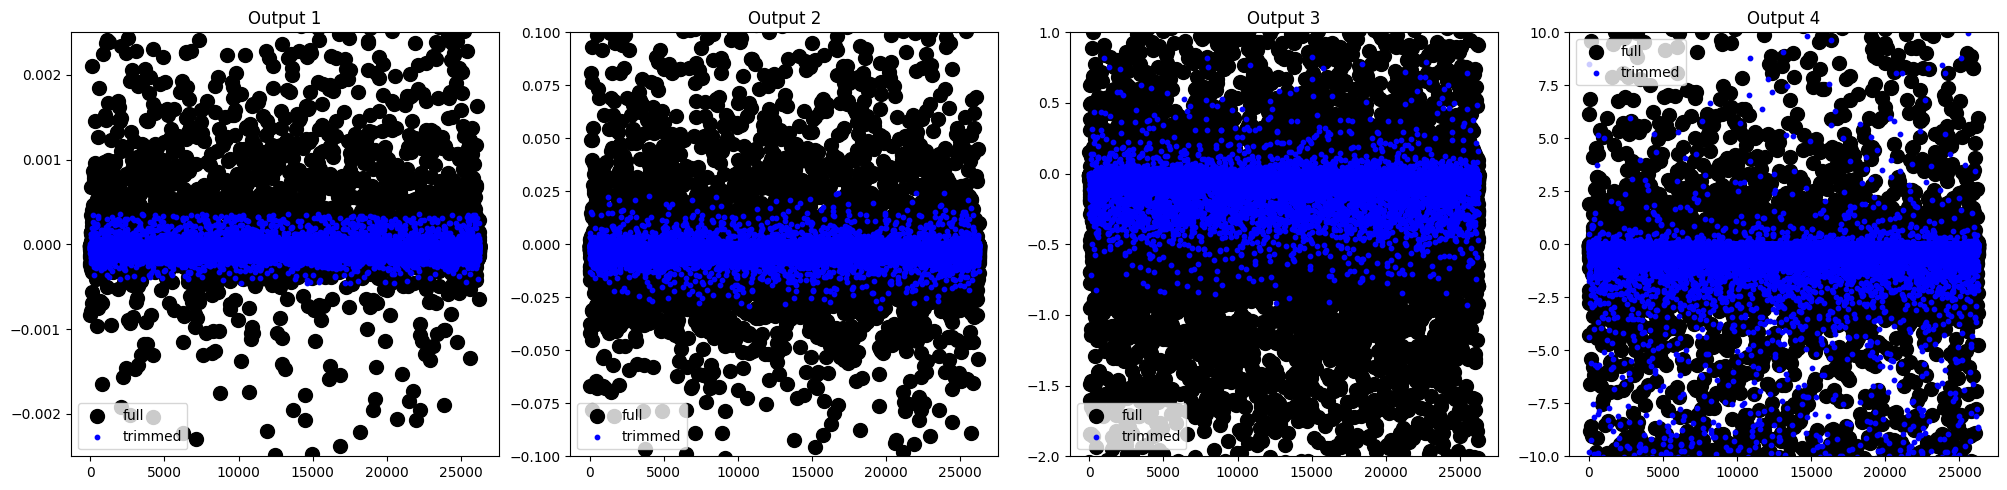

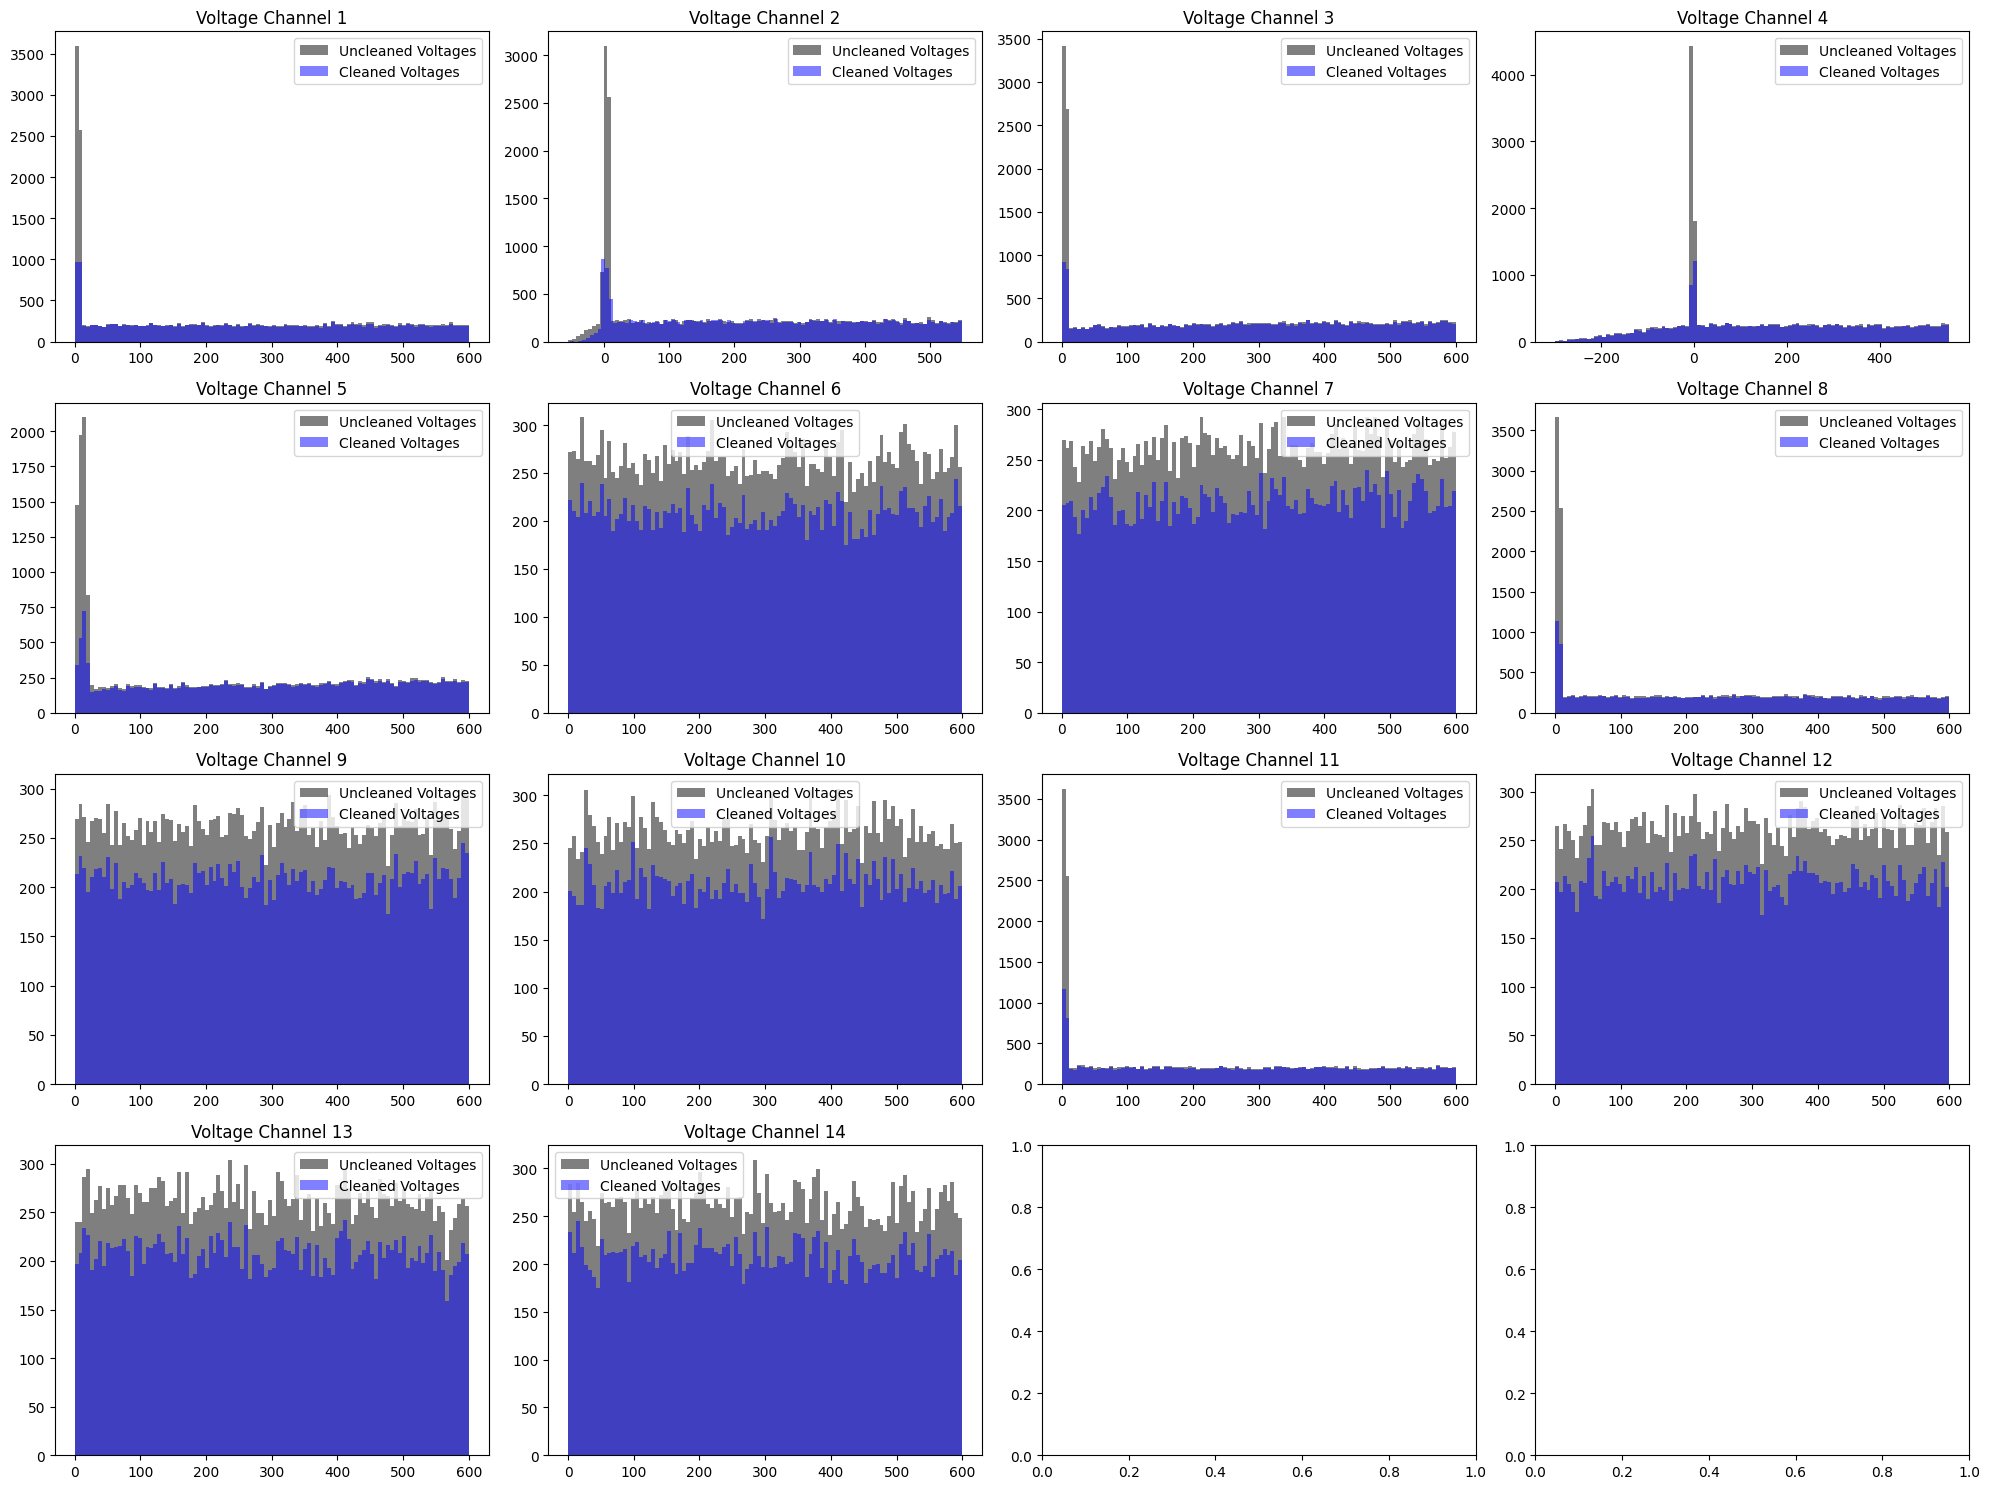

In [ ]:
threshold = [10, 10, 10, 10]  # Thresholds for each output value
trim_mode = "iqr"
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
    trim_threshold=threshold,
    trim_mode=trim_mode,
    subplot_shape=(1, 4),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)

ax[0].set_ylim(-0.0025, 0.0025)
ax[1].set_ylim(-0.1, 0.1)
ax[2].set_ylim(-2, 1)
ax[3].set_ylim(-10, 10)

_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
    trim_threshold=threshold,
    trim_mode=trim_mode,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 0.907194, Val Loss = 0.746904
Epoch 100: Train Loss = 0.538036, Val Loss = 0.480353
Epoch 200: Train Loss = 0.496181, Val Loss = 0.409095
Training completed. Best validation loss: 0.379505


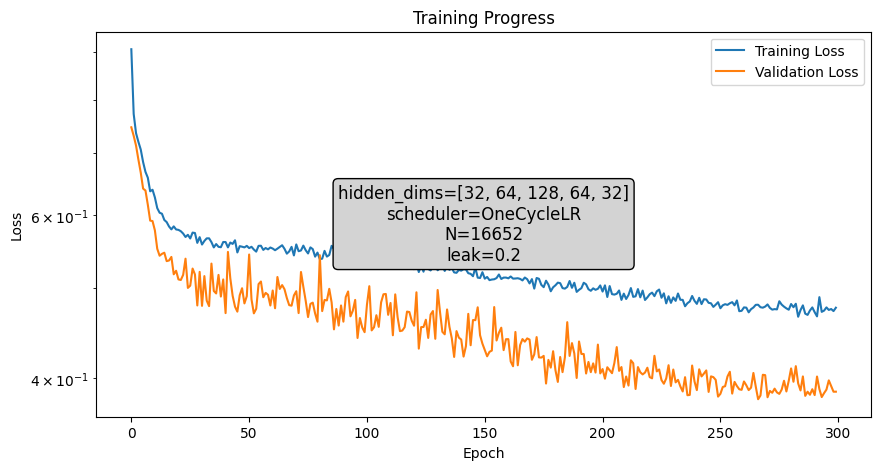

In [ ]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 4  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor2 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, leak=0.2
)
print("Training model...")
predictor2.train(
    voltages,
    outputs,
    epochs=EPOCH*2,
    verbose=True,
    checkpoint_name="best_model2.pt",
)


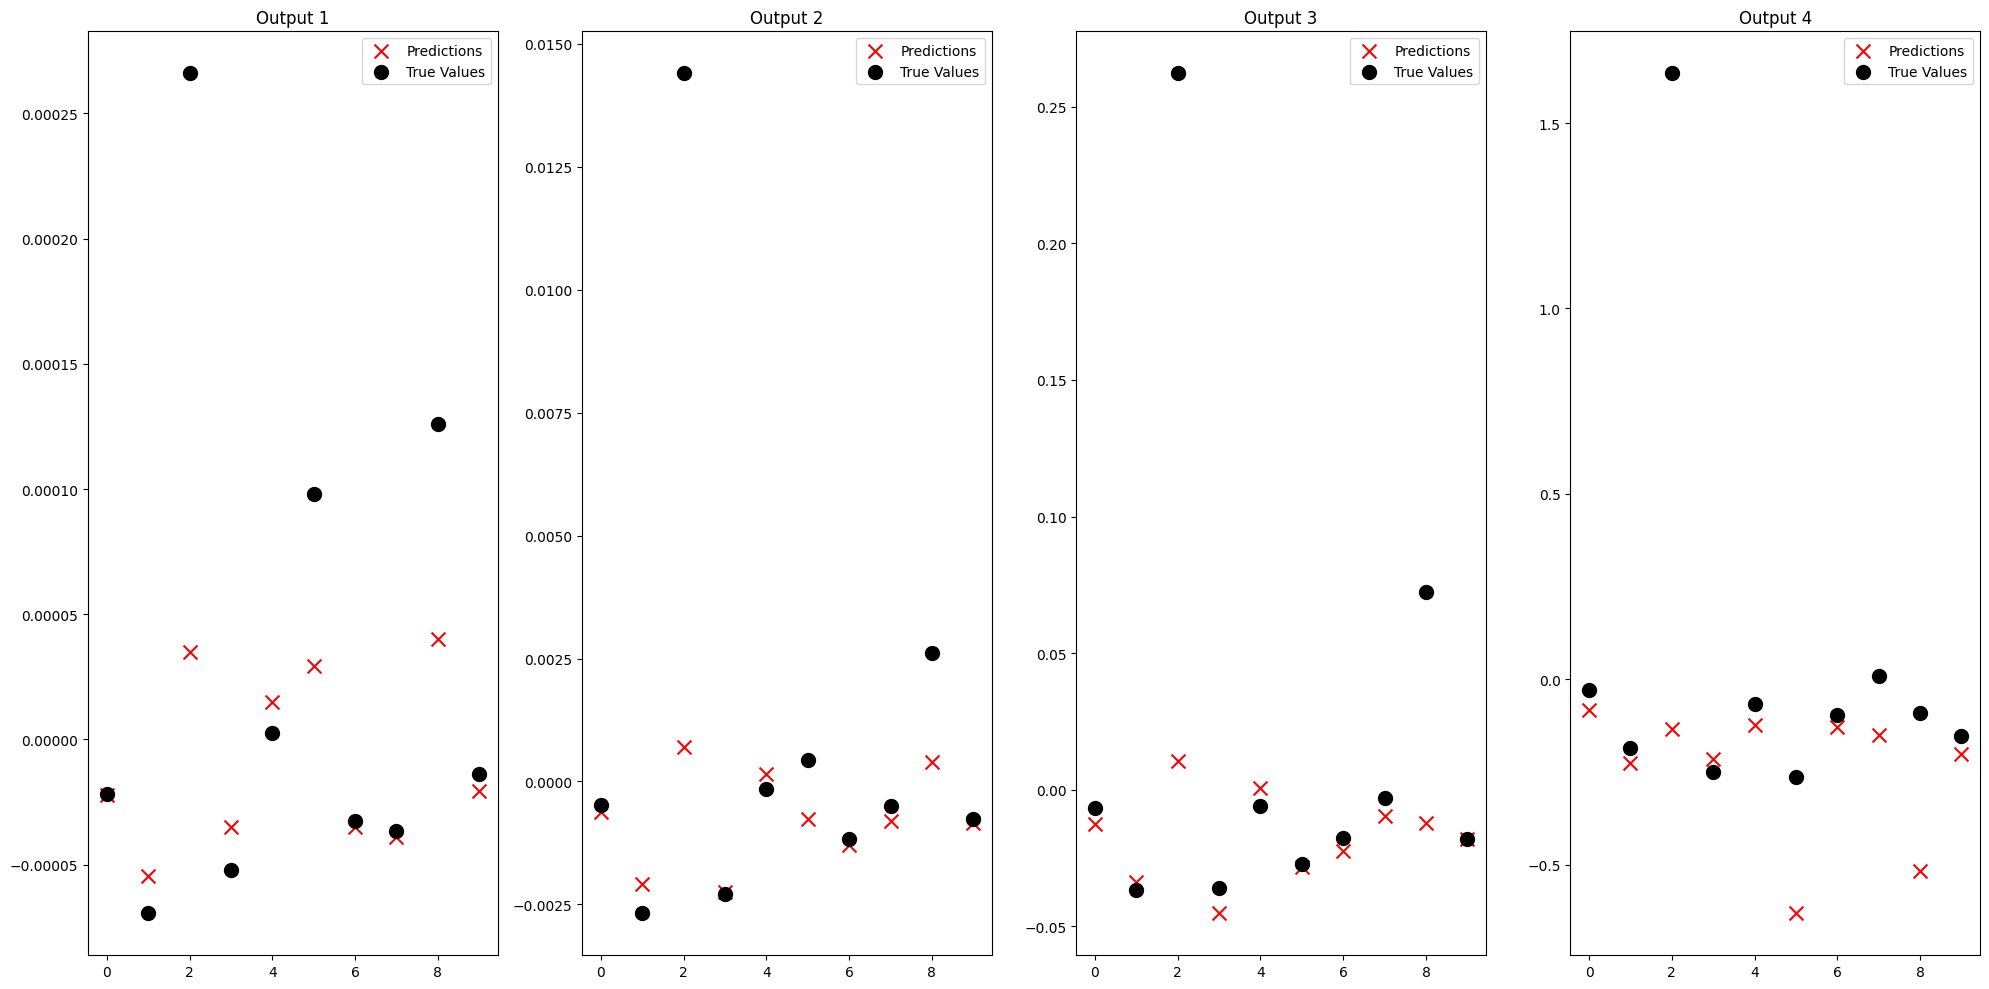

In [ ]:
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor2, n_samples=10, subplot_shape=(1, 4)
)

Cluster 3

86.4% of data retained after cleaning


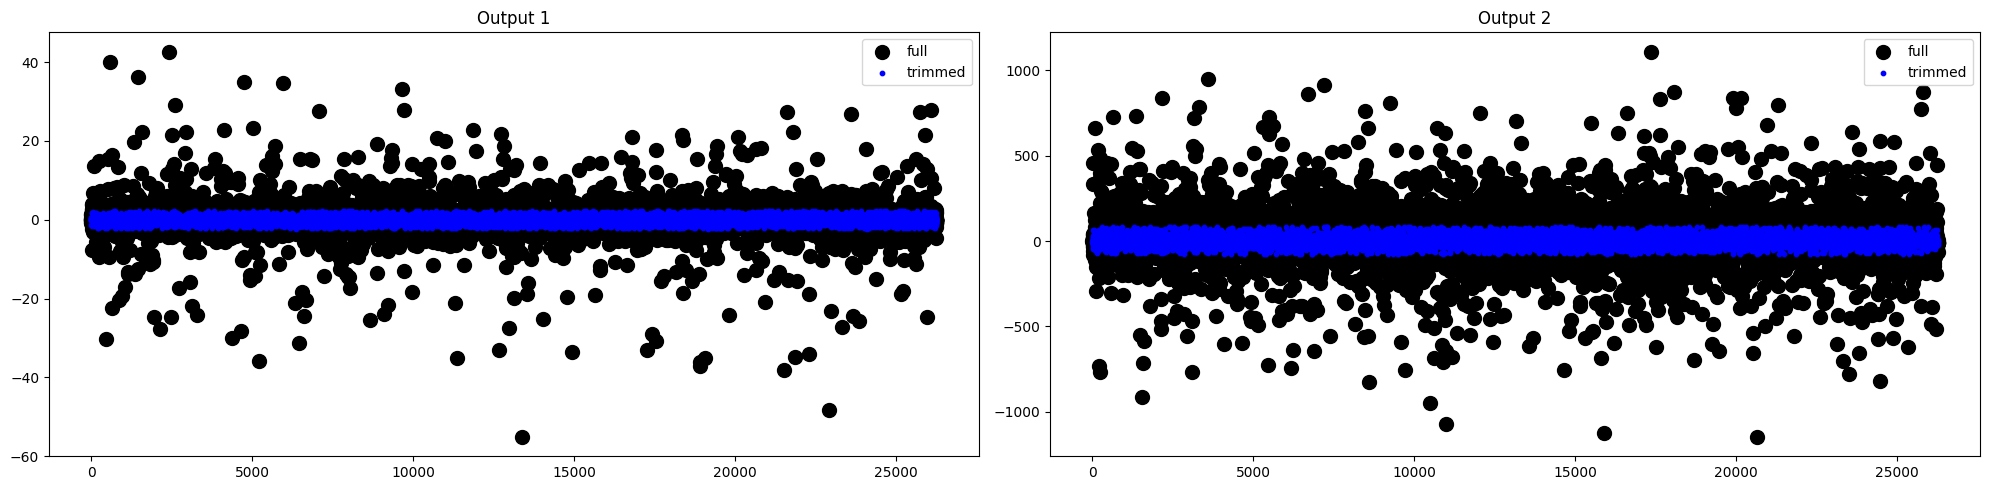

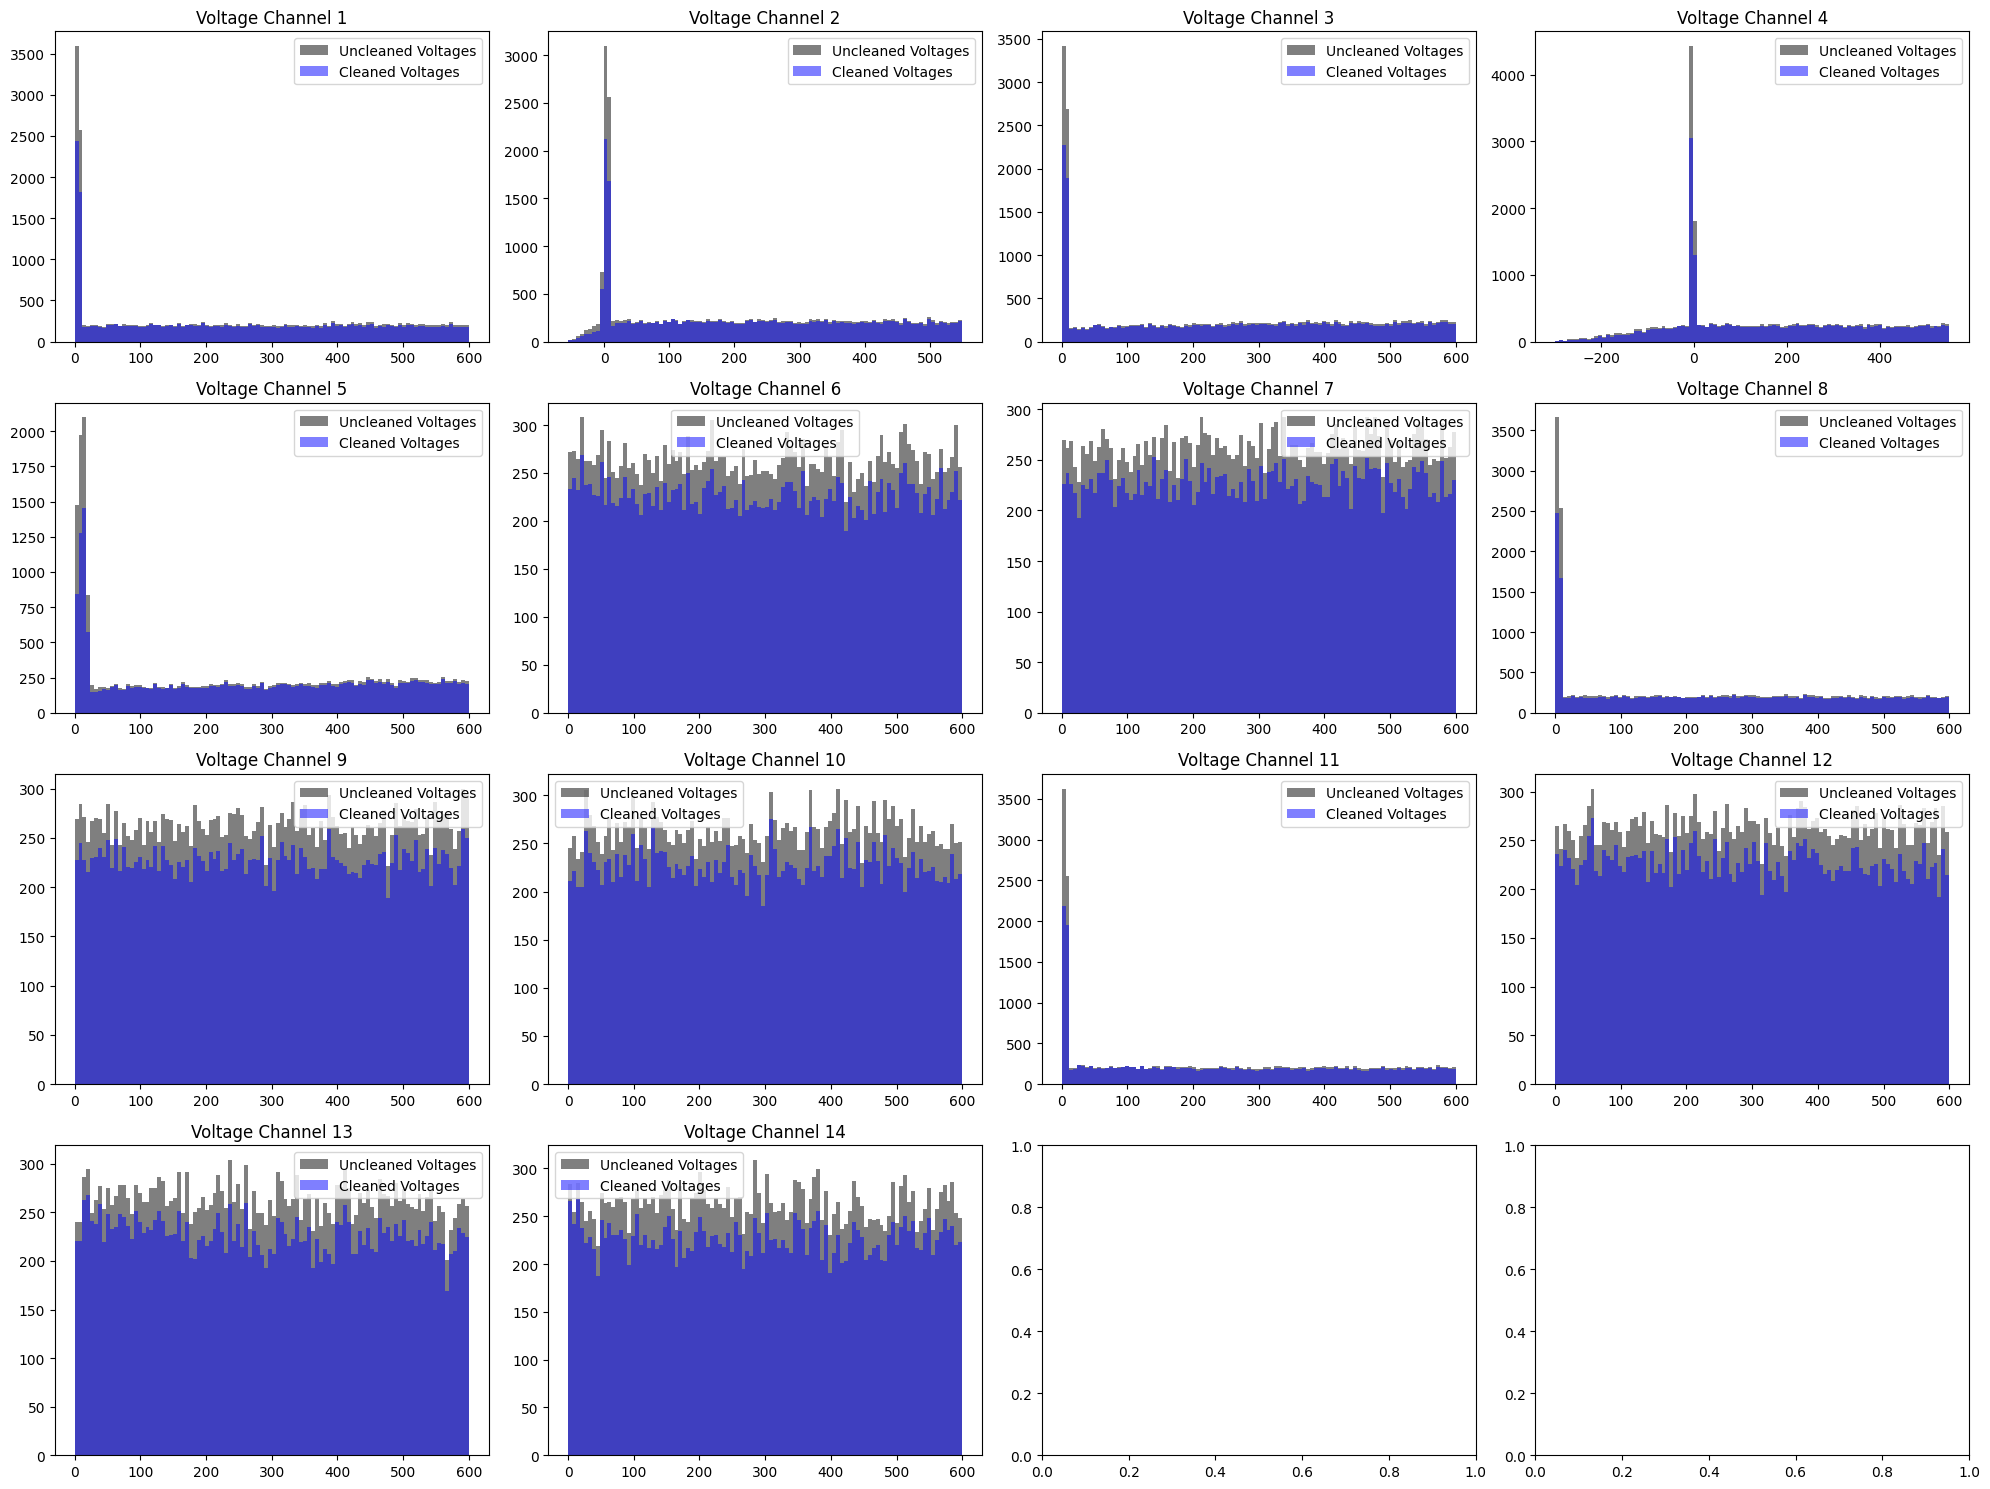

In [ ]:
threshold = 1
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
    trim_threshold=threshold,
    subplot_shape=(1, 2),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)


_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
    trim_threshold=threshold,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 1.143174, Val Loss = 0.974098
Epoch 100: Train Loss = 0.653017, Val Loss = 0.514115
Training completed. Best validation loss: 0.495762


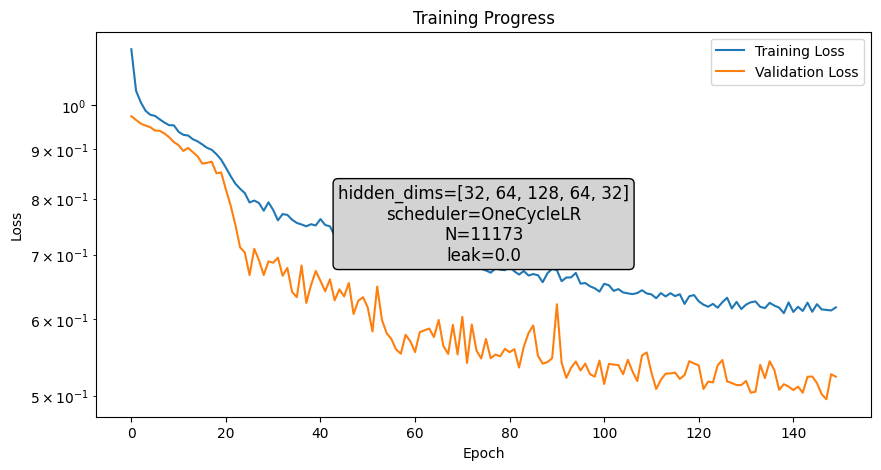

In [ ]:
n_voltages = 14  # Number of voltage parameters


n_output_values = 2  # Number of output values (e.g., magnification, aberration, etc.)


raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)


# Create and train model


predictor3 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, leak=0.0
)


print("Training model...")


predictor3.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model3.pt",
)


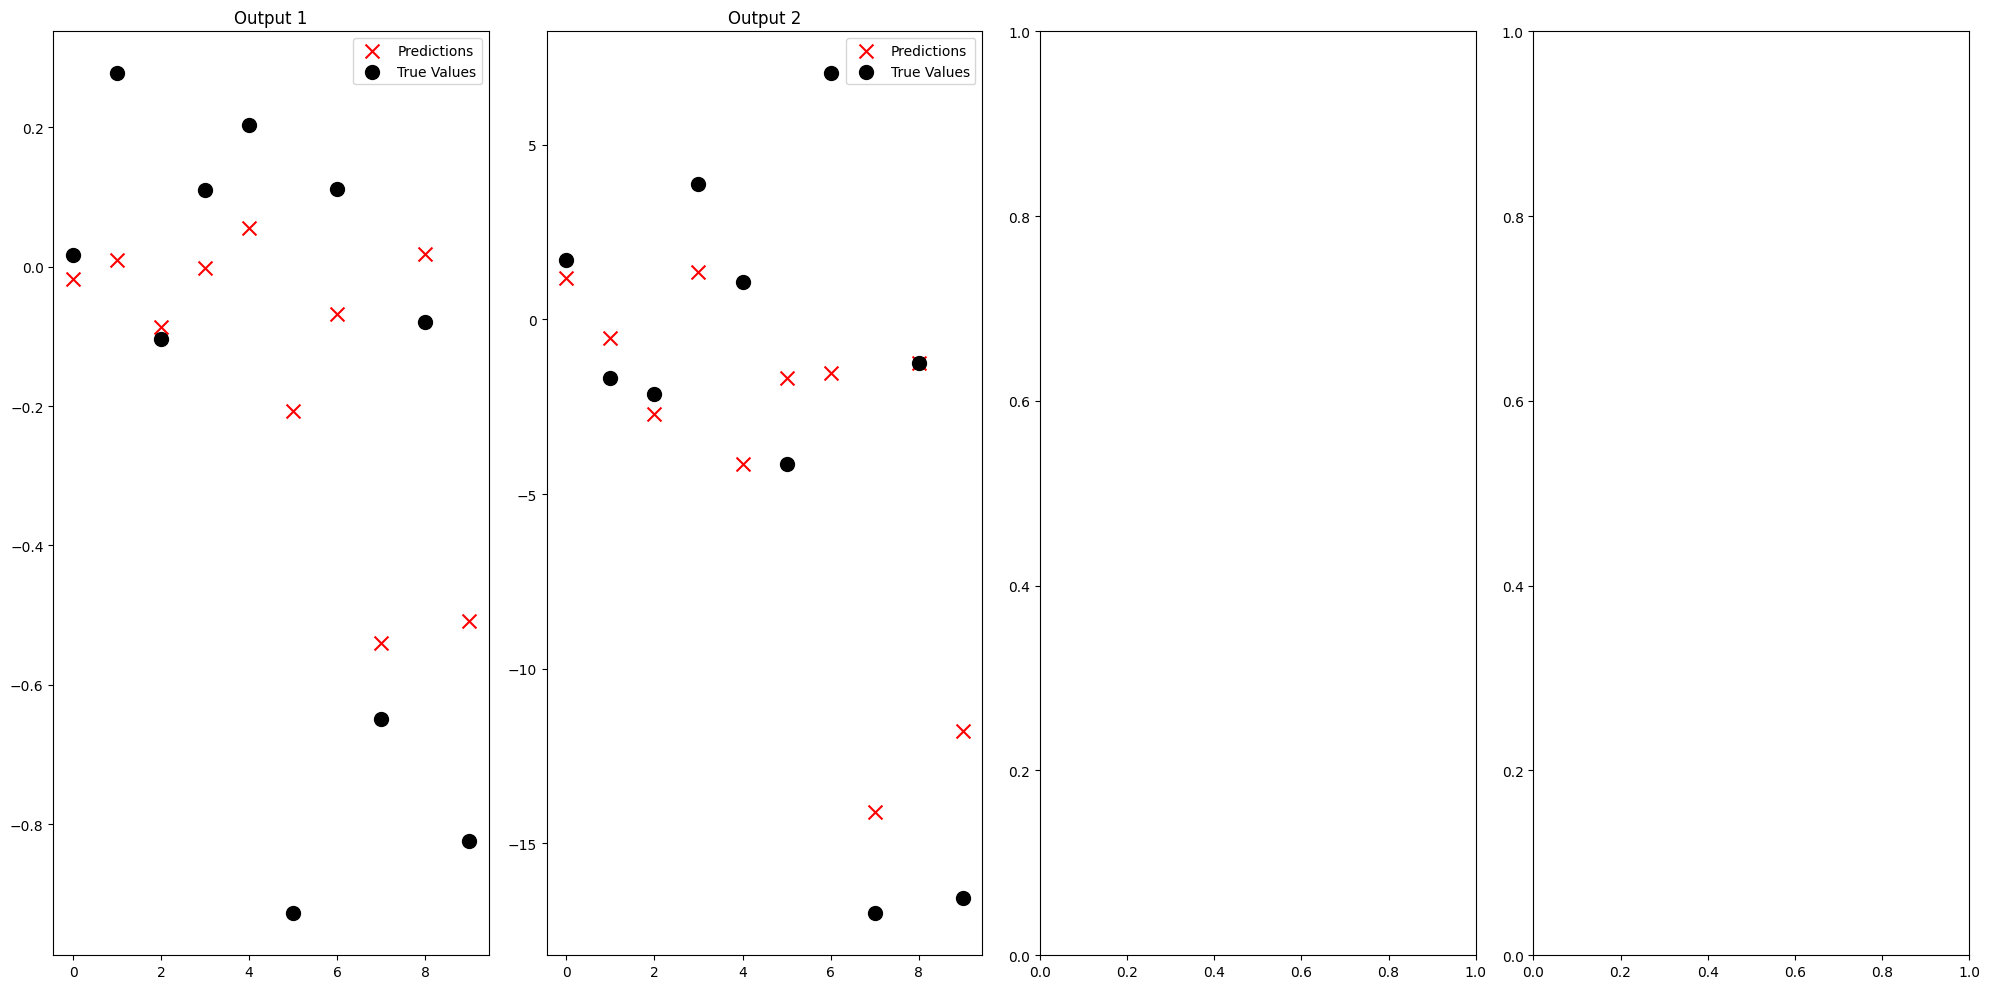

In [ ]:
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor3, n_samples=10, subplot_shape=(1, 4)
)

Cluster 4

77.3% of data retained after cleaning


(-0.2, 0.2)

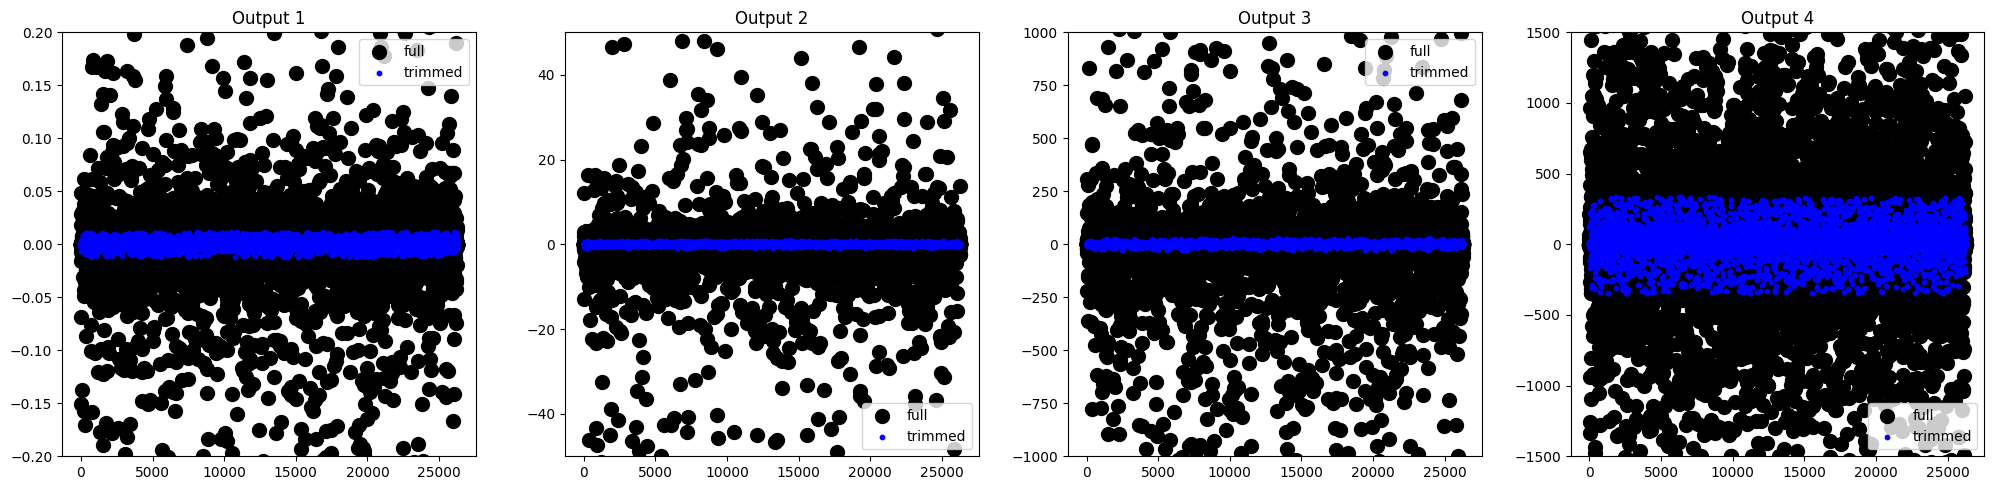

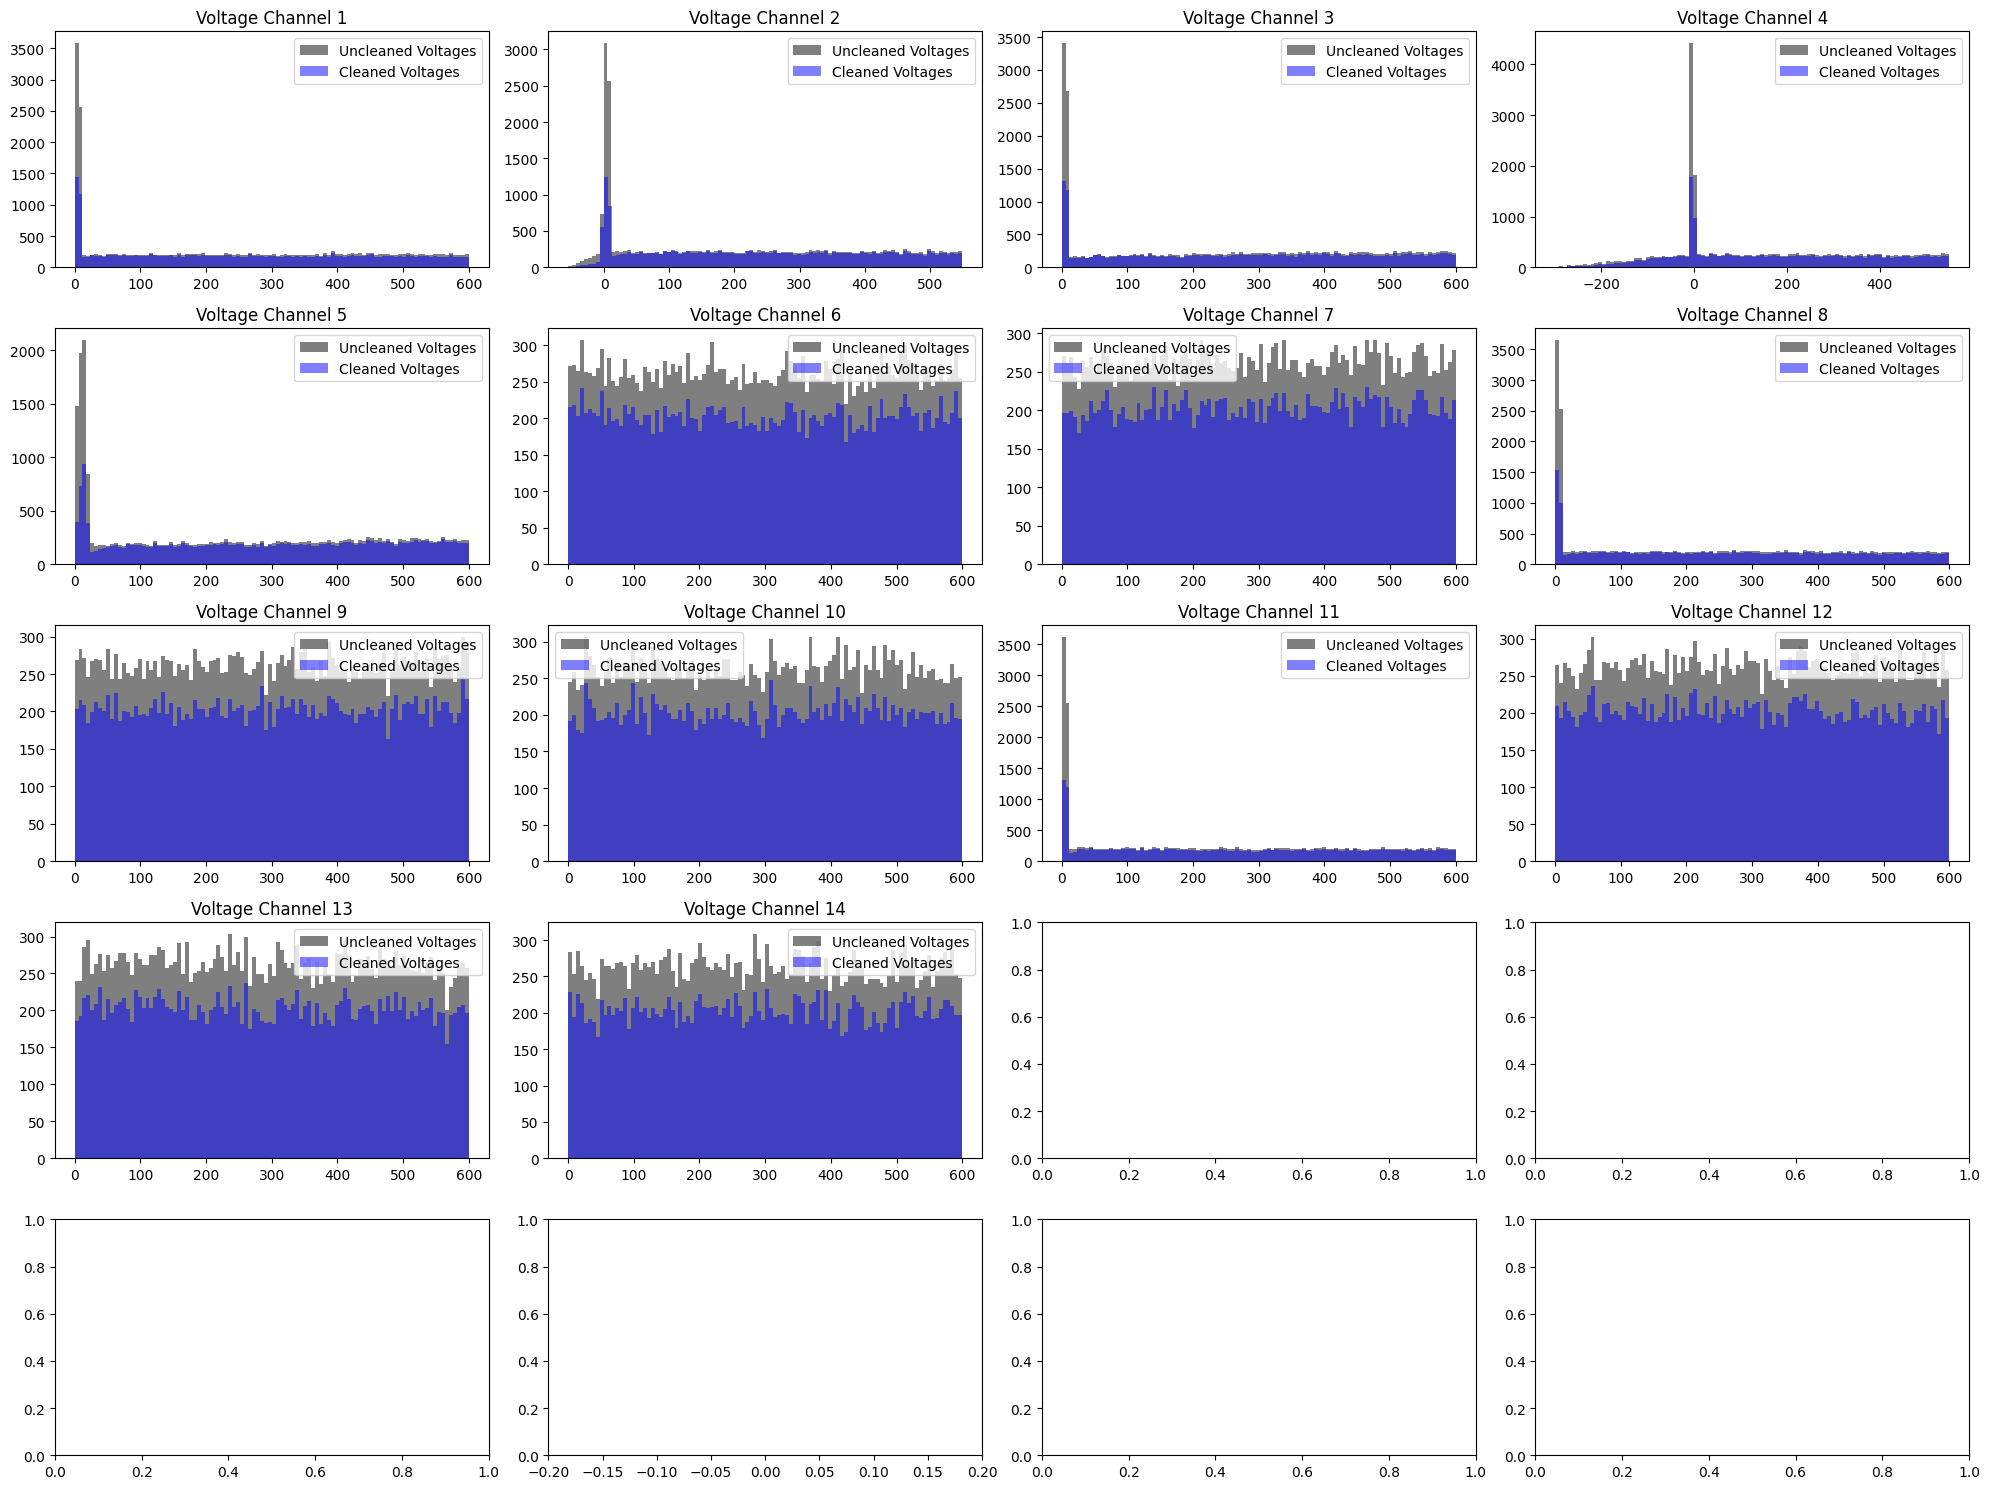

In [ ]:
threshold = 20
_, ax, _, output_values, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
    trim_mode="iqr",
    trim_threshold=threshold,
    subplot_shape=(1, 4),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)
ax[0].set_ylim(-0.2, 0.2)
ax[1].set_ylim(-50, 50)
ax[2].set_ylim(-1000, 1000)
ax[3].set_ylim(-1500, 1500)


fig, ax, voltages_unclean, output_values_unclean, voltages, output_values = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
    trim_mode="iqr",
    trim_threshold=threshold,
    subplot_shape=(5, 4),
    hist_bins=100,
)

# ax[-1].scatter(np.arange(len(output_values)), output_values[:, 0])
ax[-3].set_xlim(-0.2, 0.2)

Using device: mps
Training model...
Epoch 0: Train Loss = 1.126066, Val Loss = 0.926559
Epoch 100: Train Loss = 0.860143, Val Loss = 0.742182
Training completed. Best validation loss: 0.713684


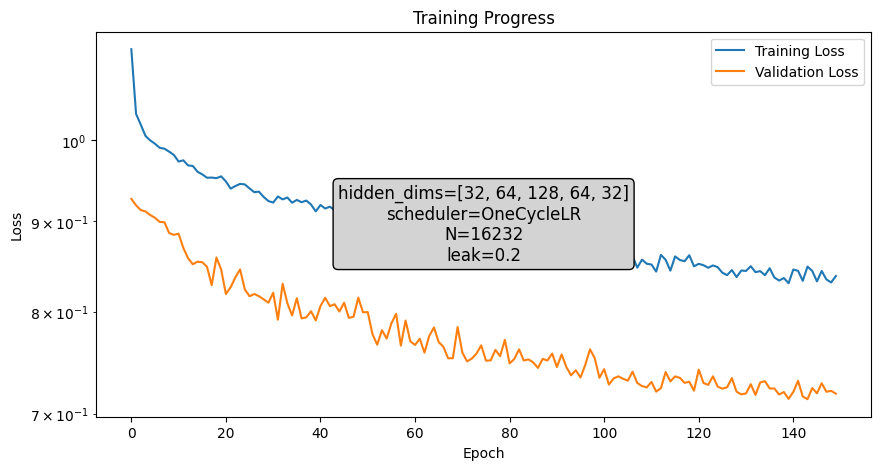

In [ ]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 4  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor4 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, leak=0.2
)
print("Training model...")
predictor4.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model4.pt",
)


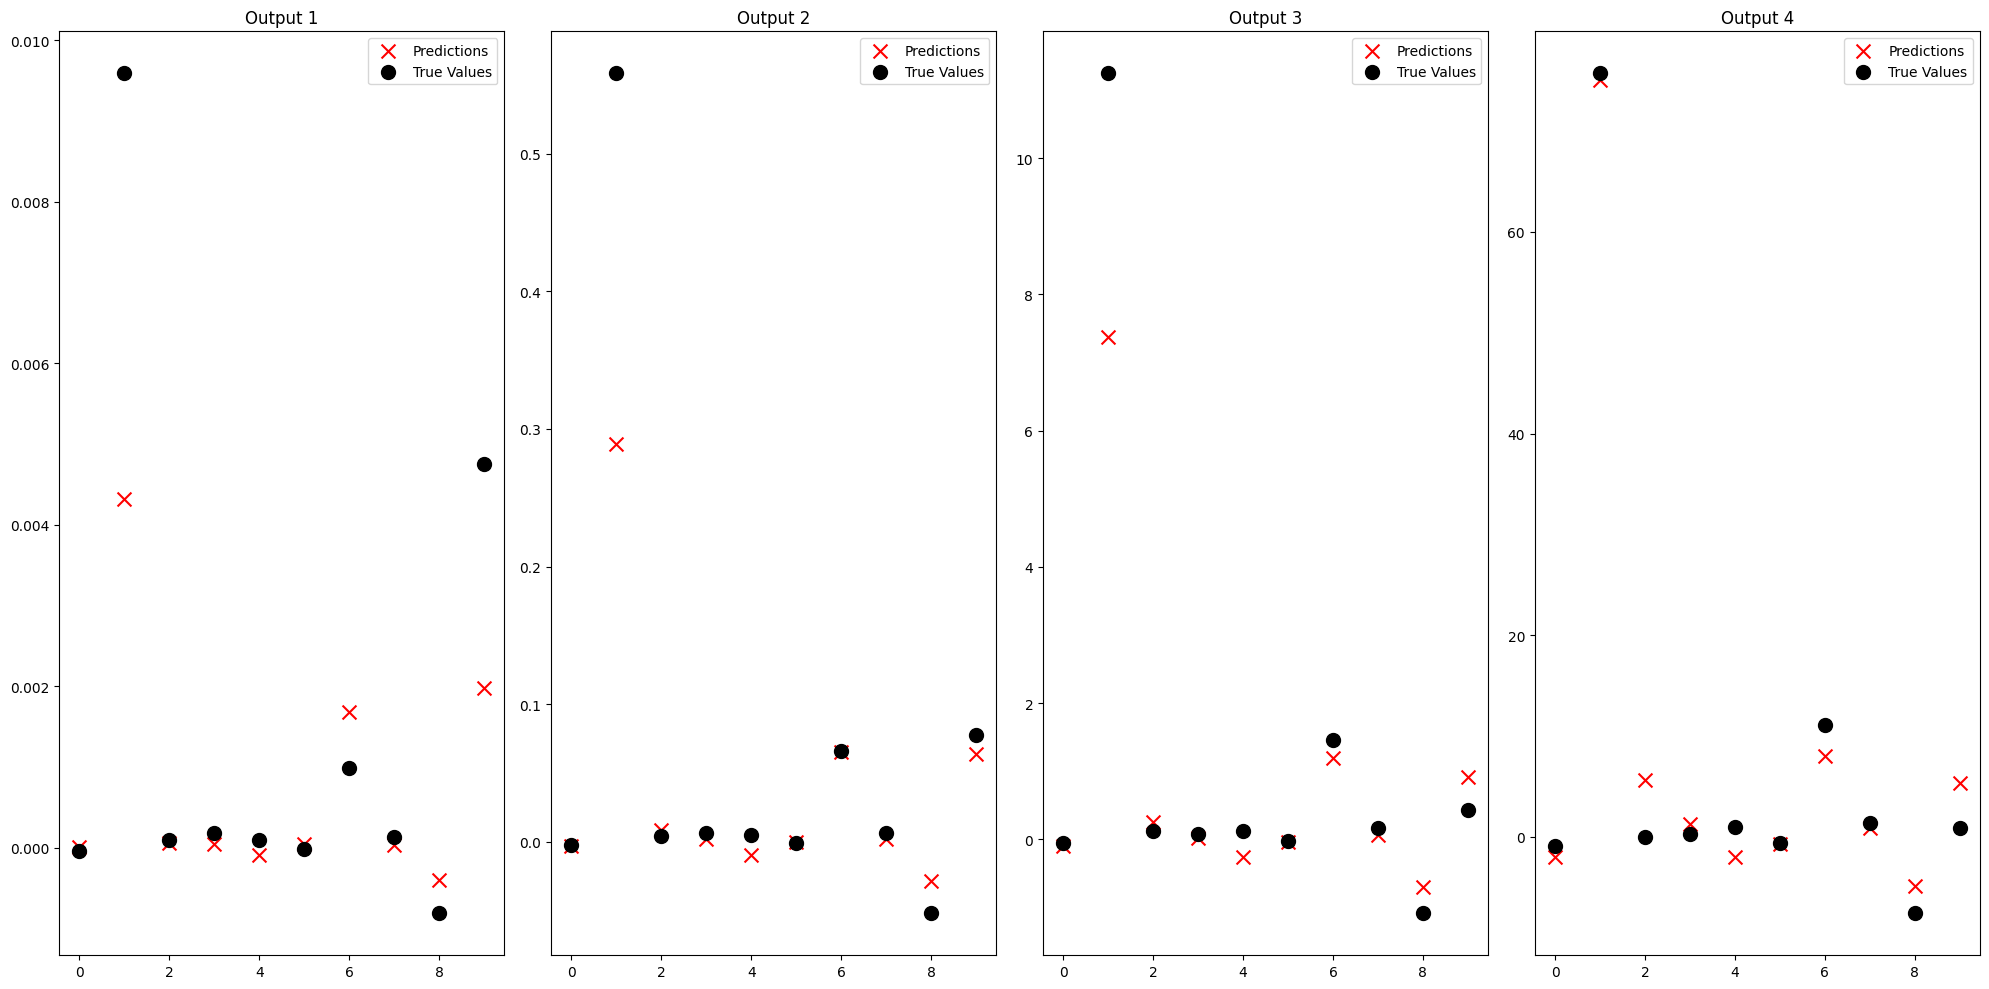

In [ ]:
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor4,
    n_samples=10,
    subplot_shape=(1, 4),
)

(array([238.61021, 375.6702 ,  95.27884, 366.68442, 436.96967, 403.98236,
        148.84229, 388.76184, 371.3396 , 312.69534, 423.3474 , 262.4552 ,
        364.58063, 243.06192], dtype=float32),
 152.18031311035156)

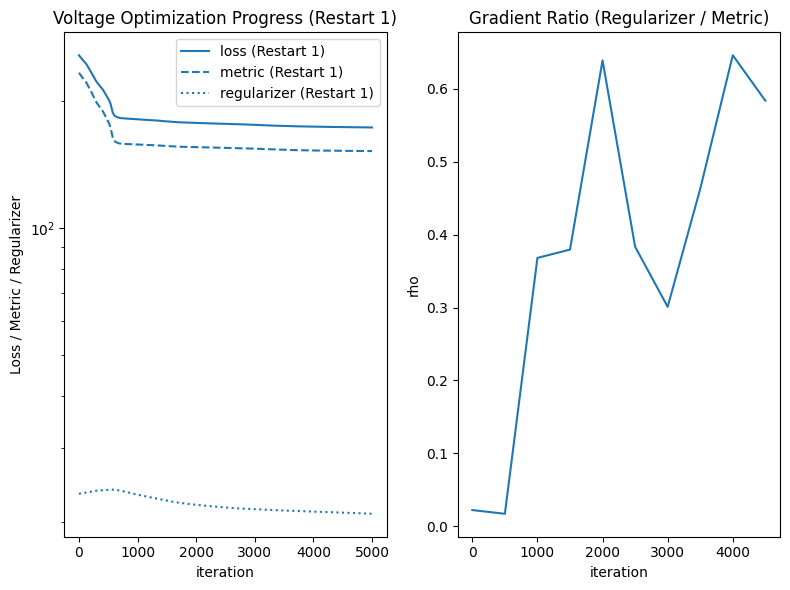

In [ ]:
best_voltages, best_values, best_objective = optimize_voltages(
    [predictor1, predictor2, predictor3, predictor4], metric, random_restarts=1, n_iterations=5000, learning_rate=0.1, voltage_bounds=[0, 600], hyperparameters={'strength': 1E0, 'min': 0, 'max': 600, 's': 1E10}
)


best_voltages, best_objective

